### 1. 데이터 찾기 - 의도가 중요 : 궁금한거, 알아보고 싶은 것 생각 -> 잘모르겠다 코덱스  -- 지역별 영화관 개수 찾기
### 2. 데이터 정제 및 전처리
### 3. 병합 및 집계
### 4. 인사이트 정리

제출하기 - 구글드라이브에 잘되던 안되던 제출하기

In [1]:
import pandas

# 1. 원본 CSV 파일을 CP949 인코딩으로 읽습니다.
df = pandas.read_csv("../data/3-6_movie_theater.csv",encoding="cp949")

#df = pd.read_csv("../data/3-4_city_park.csv")

# 2. UTF-8 형식의 새 파일로 저장합니다.
# utf-8-sig: 엑셀에서도 한글이 비교적 잘 보이는 UTF-8 방식입니다.
df.to_csv(
      "../data/3-6_movie_theater_utf8.csv",
      encoding="utf-8-sig",
      index=False
)

print("저장 완료: ../data/3-6_movie_theater_utf8.csv")
# AI 도움으로 읽기 부분 수정 요청 해서 생성된 코드 입니다.

저장 완료: ../data/3-6_movie_theater_utf8.csv


In [2]:
df = pandas.read_csv("../data/3-6_movie_theater_utf8.csv",encoding="utf8")  # 판다스 파일 읽기
df.head()  

,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태명,폐업일자,휴업시작일자,휴업종료일자,소재지우편번호,도로명우편번호,...,주변환경명,지번주소,지상층수,지역구분명,지하층수,청소년실수,총층수,최초등록시점,통로너비,최종수정시점
0,3000000,CDFF4220002010000001,2010-04-15,NaN,폐업,2022-02-17,NaN,NaN,NaN,NaN,...,NaN,서울특별시 종로구 신문로2가 1-153 2층,1.0,NaN,3.0,NaN,4.0,2010-04-15,NaN,2022-03-25 13:09:35
1,3000000,CDFF4220002011000001,2011-03-23,NaN,폐업,2012-05-29,NaN,NaN,NaN,NaN,...,NaN,서울특별시 종로구 신문로2가 1-153 가든플레이스 2층,3.0,NaN,1.0,NaN,4.0,2011-03-23,NaN,2012-06-08 14:44:56
2,3000000,CDFF4220002011000002,2011-05-23,NaN,폐업,2013-08-09,NaN,NaN,NaN,NaN,...,NaN,서울특별시 종로구 명륜3가 109-4 지하1층,3.0,NaN,1.0,NaN,4.0,2011-05-23,NaN,2013-08-09 16:53:32
3,3000000,CDFF4220002003000010,2003-02-12,NaN,영업/정상,NaN,NaN,NaN,NaN,4051.0,...,NaN,서울특별시 마포구 동교동 166-14 동교동 스타피카소,NaN,NaN,NaN,NaN,NaN,2003-02-12,NaN,2022-02-21 11:00:52
4,3000000,CDFF4220002003000013,2003-02-12,NaN,영업/정상,NaN,NaN,NaN,NaN,NaN,...,NaN,서울특별시 종로구 낙원동 284-6,NaN,NaN,NaN,NaN,NaN,2003-02-12,NaN,2020-03-23 14:02:25


In [5]:
df.columns  # 컬럼 정보 보기

Index(['개방자치단체코드', '관리번호', '인허가일자', '인허가취소일자', '영업상태명', '폐업일자', '휴업시작일자',
       '휴업종료일자', '소재지우편번호', '도로명우편번호', '사업장명', '데이터갱신구분', '건물용도명', '공연장형태구분명',
       '노래방실수', '데이터갱신시점', '도로명주소', '문화사업자구분명', '문화체육업종명', '상세영업상태명',
       '상세영업상태코드', '시설면적', '영업상태코드', '전화번호', '제작취급품목내용', '좌표정보(X)', '좌표정보(Y)',
       '주변환경명', '지번주소', '지상층수', '지역구분명', '지하층수', '청소년실수', '총층수', '최초등록시점',
       '통로너비', '최종수정시점'],
      dtype='str')

In [ ]:
df.info()   # 컬럼명 데이터 타입 새로로 보기

<class 'pandas.DataFrame'>
RangeIndex: 5233 entries, 0 to 5232
Data columns (total 37 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   개방자치단체코드  5233 non-null   int64  
 1   관리번호      5233 non-null   str    
 2   인허가일자     5233 non-null   str    
 3   인허가취소일자   0 non-null      float64
 4   영업상태명     5233 non-null   str    
 5   폐업일자      1532 non-null   str    
 6   휴업시작일자    73 non-null     str    
 7   휴업종료일자    66 non-null     str    
 8   소재지우편번호   1107 non-null   str    
 9   도로명우편번호   3528 non-null   float64
 10  사업장명      5233 non-null   str    
 11  데이터갱신구분   5233 non-null   str    
 12  건물용도명     2730 non-null   str    
 13  공연장형태구분명  5173 non-null   str    
 14  노래방실수     0 non-null      float64
 15  데이터갱신시점   5233 non-null   str    
 16  도로명주소     4871 non-null   str    
 17  문화사업자구분명  2834 non-null   str    
 18  문화체육업종명   5233 non-null   str    
 19  상세영업상태명   5219 non-null   str    
 20  상세영업상태코드  5233 non-null   str    
 21  시설

In [3]:
# info()에서 표시할 최대 컬럼 수를 늘리기
pandas.set_option("display.max_info_columns", 200)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5233 entries, 0 to 5232
Data columns (total 37 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   개방자치단체코드  5233 non-null   int64  
 1   관리번호      5233 non-null   str    
 2   인허가일자     5233 non-null   str    
 3   인허가취소일자   0 non-null      float64
 4   영업상태명     5233 non-null   str    
 5   폐업일자      1532 non-null   str    
 6   휴업시작일자    73 non-null     str    
 7   휴업종료일자    66 non-null     str    
 8   소재지우편번호   1107 non-null   str    
 9   도로명우편번호   3528 non-null   float64
 10  사업장명      5233 non-null   str    
 11  데이터갱신구분   5233 non-null   str    
 12  건물용도명     2730 non-null   str    
 13  공연장형태구분명  5173 non-null   str    
 14  노래방실수     0 non-null      float64
 15  데이터갱신시점   5233 non-null   str    
 16  도로명주소     4871 non-null   str    
 17  문화사업자구분명  2834 non-null   str    
 18  문화체육업종명   5233 non-null   str    
 19  상세영업상태명   5219 non-null   str    
 20  상세영업상태코드  5233 non-null   str    
 21  시설

In [4]:
# 0번부터 20번까지 출력
for i, col in enumerate(df.columns[:20]):
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else "None"
    print(f"[{i:2d}] {col} ({df[col].dtype}) ➔ 예시: {sample}")

print("-" * 50)

[ 0] 개방자치단체코드 (int64) ➔ 예시: 3000000
[ 1] 관리번호 (str) ➔ 예시: CDFF4220002010000001
[ 2] 인허가일자 (str) ➔ 예시: 2010-04-15
[ 3] 인허가취소일자 (float64) ➔ 예시: None
[ 4] 영업상태명 (str) ➔ 예시: 폐업
[ 5] 폐업일자 (str) ➔ 예시: 2022-02-17
[ 6] 휴업시작일자 (str) ➔ 예시: 2025-03-15
[ 7] 휴업종료일자 (str) ➔ 예시: 2027-01-31
[ 8] 소재지우편번호 (str) ➔ 예시: 110-833
[ 9] 도로명우편번호 (float64) ➔ 예시: 4051.0
[10] 사업장명 (str) ➔ 예시: 독립영화전용관 시네마루
[11] 데이터갱신구분 (str) ➔ 예시: I
[12] 건물용도명 (str) ➔ 예시: 문화시설
[13] 공연장형태구분명 (str) ➔ 예시: 영화관
[14] 노래방실수 (float64) ➔ 예시: None
[15] 데이터갱신시점 (str) ➔ 예시: 2026-05-10 22:41:08
[16] 도로명주소 (str) ➔ 예시: 서울특별시 종로구 경희궁1길 1 (신문로2가,2층)
[17] 문화사업자구분명 (str) ➔ 예시: 영화상영관
[18] 문화체육업종명 (str) ➔ 예시: 영화상영관
[19] 상세영업상태명 (str) ➔ 예시: 폐업
--------------------------------------------------


In [5]:
# 20번부터 끝까지 출력
for i, col in enumerate(df.columns[20:], start=20):
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else "None"
    print(f"[{i:2d}] {col} ({df[col].dtype}) ➔ 예시: {sample}")

[20] 상세영업상태코드 (str) ➔ 예시: 03
[21] 시설면적 (float64) ➔ 예시: 356.4
[22] 영업상태코드 (int64) ➔ 예시: 3
[23] 전화번호 (float64) ➔ 예시: 32103358.0
[24] 제작취급품목내용 (float64) ➔ 예시: None
[25] 좌표정보(X) (float64) ➔ 예시: 197428.923002637
[26] 좌표정보(Y) (float64) ➔ 예시: 452041.177877529
[27] 주변환경명 (str) ➔ 예시: 기타
[28] 지번주소 (str) ➔ 예시: 서울특별시 종로구 신문로2가 1-153 2층 
[29] 지상층수 (float64) ➔ 예시: 1.0
[30] 지역구분명 (str) ➔ 예시: 근린상업지역
[31] 지하층수 (float64) ➔ 예시: 3.0
[32] 청소년실수 (float64) ➔ 예시: None
[33] 총층수 (float64) ➔ 예시: 4.0
[34] 최초등록시점 (str) ➔ 예시: 2010-04-15
[35] 통로너비 (float64) ➔ 예시: 1.0
[36] 최종수정시점 (str) ➔ 예시: 2022-03-25 13:09:35


In [6]:
# 최대 출력 컬럼 수 제한 해제 (가장 중요)
pandas.set_option("display.max_columns", None)

# 컬럼 내부 글자 잘림 방지 (선택)
pandas.set_option("display.max_colwidth", None)

df.head()

,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태명,폐업일자,휴업시작일자,휴업종료일자,소재지우편번호,도로명우편번호,사업장명,데이터갱신구분,건물용도명,공연장형태구분명,노래방실수,데이터갱신시점,도로명주소,문화사업자구분명,문화체육업종명,상세영업상태명,상세영업상태코드,시설면적,영업상태코드,전화번호,제작취급품목내용,좌표정보(X),좌표정보(Y),주변환경명,지번주소,지상층수,지역구분명,지하층수,청소년실수,총층수,최초등록시점,통로너비,최종수정시점
0,3000000,CDFF4220002010000001,2010-04-15,NaN,폐업,2022-02-17,NaN,NaN,NaN,NaN,독립영화전용관 시네마루,I,NaN,영화관,NaN,2026-05-10 22:41:08,"서울특별시 종로구 경희궁1길 1 (신문로2가,2층)",NaN,영화상영관,폐업,03,NaN,3,3.210336e+07,NaN,197428.923003,452041.177878,NaN,서울특별시 종로구 신문로2가 1-153 2층,1.0,NaN,3.0,NaN,4.0,2010-04-15,NaN,2022-03-25 13:09:35
1,3000000,CDFF4220002011000001,2011-03-23,NaN,폐업,2012-05-29,NaN,NaN,NaN,NaN,미로스페이스,I,문화시설,영화관,NaN,2026-05-10 22:41:08,"서울특별시 종로구 경희궁1길 1, 2층 (신문로2가, 가든플레이스)",NaN,영화상영관,폐업,03,NaN,3,3.210336e+07,NaN,197428.923003,452041.177878,NaN,서울특별시 종로구 신문로2가 1-153 가든플레이스 2층,3.0,NaN,1.0,NaN,4.0,2011-03-23,NaN,2012-06-08 14:44:56
2,3000000,CDFF4220002011000002,2011-05-23,NaN,폐업,2013-08-09,NaN,NaN,NaN,NaN,3D상상극장,I,근린생활시설,영화관,NaN,2026-05-10 22:41:09,"서울특별시 종로구 성균관로3길 20-4 (명륜3가,지하1층)",NaN,영화상영관,폐업,03,NaN,3,NaN,NaN,199666.948921,453452.586228,NaN,서울특별시 종로구 명륜3가 109-4 지하1층,3.0,NaN,1.0,NaN,4.0,2011-05-23,NaN,2013-08-09 16:53:32
3,3000000,CDFF4220002003000010,2003-02-12,NaN,영업/정상,NaN,NaN,NaN,NaN,4051.0,독립영화전용관 인디스페이스,I,NaN,영화관,NaN,2026-05-10 22:40:55,"서울특별시 마포구 양화로 176, 동교동 스타피카소 8층 (동교동)",영화상영관,영화상영관,영업중,13,NaN,1,7.082360e+09,NaN,193282.130800,450549.280167,NaN,서울특별시 마포구 동교동 166-14 동교동 스타피카소,NaN,NaN,NaN,NaN,NaN,2003-02-12,NaN,2022-02-21 11:00:52
4,3000000,CDFF4220002003000013,2003-02-12,NaN,영업/정상,NaN,NaN,NaN,NaN,NaN,허리우드클래식,I,NaN,영화관,NaN,2026-05-10 22:40:56,서울특별시 종로구 삼일대로 428 (낙원동),영화상영관,영화상영관,영업중,13,NaN,1,3.672423e+07,NaN,198852.959717,452253.942585,NaN,서울특별시 종로구 낙원동 284-6,NaN,NaN,NaN,NaN,NaN,2003-02-12,NaN,2020-03-23 14:02:25


In [7]:
columns = ["영업상태명","사업장명","도로명주소","데이터갱신시점","지번주소","지상층수"] # 필요한 컬럼만 가져오기
df[columns]                         # 확인
save_column_df = df[columns]        # 해당되는 컬럼만 보기    
len(save_column_df[save_column_df["영업상태명"] == "폐업"])         # 폐업한 영화관 건수                     



1457

In [8]:
len(save_column_df[save_column_df["영업상태명"] == "영업/정상"])     # 영업중인 영화관 건수


3510

In [9]:
len(save_column_df)     # 등록된 전체 영화관 건수

5233

In [11]:
save_column_df["영화관지역"] = save_column_df["지번주소"].str.split(" ").str[0]     # 지번주소 앞자리로 영화관 지역 구분
save_column_df

,영업상태명,사업장명,도로명주소,데이터갱신시점,지번주소,지상층수,영화관지역
0,폐업,독립영화전용관 시네마루,"서울특별시 종로구 경희궁1길 1 (신문로2가,2층)",2026-05-10 22:41:08,서울특별시 종로구 신문로2가 1-153 2층,1.0,서울특별시
1,폐업,미로스페이스,"서울특별시 종로구 경희궁1길 1, 2층 (신문로2가, 가든플레이스)",2026-05-10 22:41:08,서울특별시 종로구 신문로2가 1-153 가든플레이스 2층,3.0,서울특별시
2,폐업,3D상상극장,"서울특별시 종로구 성균관로3길 20-4 (명륜3가,지하1층)",2026-05-10 22:41:09,서울특별시 종로구 명륜3가 109-4 지하1층,3.0,서울특별시
3,영업/정상,독립영화전용관 인디스페이스,"서울특별시 마포구 양화로 176, 동교동 스타피카소 8층 (동교동)",2026-05-10 22:40:55,서울특별시 마포구 동교동 166-14 동교동 스타피카소,NaN,서울특별시
4,영업/정상,허리우드클래식,서울특별시 종로구 삼일대로 428 (낙원동),2026-05-10 22:40:56,서울특별시 종로구 낙원동 284-6,NaN,서울특별시
...,...,...,...,...,...,...,...
5228,폐업,롯데시네마 서귀포 2관,제주특별자치도 서귀포시 월드컵로 31 (법환동),2026-05-07 22:41:13,제주특별자치도 서귀포시 법환동 914,NaN,제주특별자치도
5229,영업/정상,시네메드자동차극장,NaN,2026-05-07 22:41:13,제주특별자치도 서귀포시 색달동 2889-1,NaN,제주특별자치도
5230,영업/정상,롯데시네마 서귀포 1관,제주특별자치도 서귀포시 월드컵로 31 (법환동),2026-05-07 22:41:13,제주특별자치도 서귀포시 법환동 914,NaN,제주특별자치도
5231,영업/정상,롯데시네마 서귀포2관,제주특별자치도 서귀포시 월드컵로 31 (법환동),2026-05-07 22:41:13,제주특별자치도 서귀포시 법환동 914,NaN,제주특별자치도


In [12]:
save_column_df["영화관지역"].value_counts(dropna=False) # dropna=False를 넣어야 NaN(결측치) 개수까지 함께 보입니다.

영화관지역
경기도          1353
서울특별시         947
전남광주통합특별시     394
부산광역시         318
경상남도          317
인천광역시         279
대구광역시         254
전북특별자치도       217
경상북도          207
충청남도          206
강원특별자치도       189
충청북도          184
대전광역시         161
울산광역시          96
제주특별자치도        81
세종특별자치시        26
0-0             1
408-196         1
광주광역시           1
전라북도            1
Name: count, dtype: int64

In [13]:
save_column_df[save_column_df["영화관지역"] == '0-0']  # 이상 데이터 확인

,영업상태명,사업장명,도로명주소,데이터갱신시점,지번주소,지상층수,영화관지역
560,영업/정상,이상윤,NaN,2026-05-03 22:30:10,0-0,0.0,0-0


In [14]:
save_column_df[save_column_df["영화관지역"] == '408-196']

,영업상태명,사업장명,도로명주소,데이터갱신시점,지번주소,지상층수,영화관지역
561,영업/정상,시네마그래픽,NaN,2026-05-03 22:30:10,408-196 양천구 목1동,NaN,408-196


In [15]:
save_column_df = save_column_df.drop([560,561])

In [16]:
save_column_df["영화관지역"].value_counts(dropna=False)         # 지역별 영화관수 확인

영화관지역
경기도          1353
서울특별시         947
전남광주통합특별시     394
부산광역시         318
경상남도          317
인천광역시         279
대구광역시         254
전북특별자치도       217
경상북도          207
충청남도          206
강원특별자치도       189
충청북도          184
대전광역시         161
울산광역시          96
제주특별자치도        81
세종특별자치시        26
광주광역시           1
전라북도            1
Name: count, dtype: int64

In [17]:
save_column_df.groupby("영화관지역")["사업장명"].count()

영화관지역
강원특별자치도       189
경기도          1353
경상남도          317
경상북도          207
광주광역시           1
대구광역시         254
대전광역시         161
부산광역시         318
서울특별시         947
세종특별자치시        26
울산광역시          96
인천광역시         279
전남광주통합특별시     394
전라북도            1
전북특별자치도       217
제주특별자치도        81
충청남도          206
충청북도          184
Name: 사업장명, dtype: int64

In [18]:
save_column_df.groupby(["영화관지역", "영업상태명"])["사업장명"].count().unstack()

영업상태명,영업/정상,취소/말소/만료/정지/중지,폐업,휴업
영화관지역,,,,
강원특별자치도,145.0,4.0,38.0,2.0
경기도,908.0,43.0,370.0,32.0
경상남도,206.0,14.0,97.0,NaN
경상북도,147.0,4.0,50.0,6.0
광주광역시,1.0,NaN,NaN,NaN
대구광역시,148.0,2.0,96.0,8.0
대전광역시,105.0,1.0,55.0,NaN
부산광역시,224.0,1.0,92.0,1.0
서울특별시,624.0,22.0,301.0,NaN


In [19]:
save_column_df.groupby(["영화관지역", "영업상태명"])["사업장명"].count()

영화관지역      영업상태명         
강원특별자치도    영업/정상             145
           취소/말소/만료/정지/중지      4
           폐업                 38
           휴업                  2
경기도        영업/정상             908
           취소/말소/만료/정지/중지     43
           폐업                370
           휴업                 32
경상남도       영업/정상             206
           취소/말소/만료/정지/중지     14
           폐업                 97
경상북도       영업/정상             147
           취소/말소/만료/정지/중지      4
           폐업                 50
           휴업                  6
광주광역시      영업/정상               1
대구광역시      영업/정상             148
           취소/말소/만료/정지/중지      2
           폐업                 96
           휴업                  8
대전광역시      영업/정상             105
           취소/말소/만료/정지/중지      1
           폐업                 55
부산광역시      영업/정상             224
           취소/말소/만료/정지/중지      1
           폐업                 92
           휴업                  1
서울특별시      영업/정상             624
           취소/말소/만료/정지/중지     22
           폐업    

In [20]:
# 영화관 장사 안된다는데 지역별 영화관 영업 상태 현황 조사
save_column_df.groupby(["영화관지역", "영업상태명"])["사업장명"].count().reset_index().sort_values(["영화관지역","영업상태명"])

,영화관지역,영업상태명,사업장명
0,강원특별자치도,영업/정상,145
1,강원특별자치도,취소/말소/만료/정지/중지,4
2,강원특별자치도,폐업,38
3,강원특별자치도,휴업,2
4,경기도,영업/정상,908
5,경기도,취소/말소/만료/정지/중지,43
6,경기도,폐업,370
7,경기도,휴업,32
8,경상남도,영업/정상,206
9,경상남도,취소/말소/만료/정지/중지,14


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

In [22]:
import plotly.express as px         # 실제로 가장 많이 사용 
import plotly.graph_objects as go   # 그래프 생성의 세세한 부분까지 다 제어가능


In [23]:
import plotly.express as px

In [26]:
# 1. 차트 기본 생성 및 스타일 지정
fig = px.scatter(
    data_frame=save_column_df,
    x="영화관지역",
    y="영업상태명",
    trendline="ols",
    trendline_color_override="#E63946",  # 추세선 색상 (강렬한 레드)
    title="<b>영화관지역과 영업상태명의 상관관계</b>",  # 볼드 처리
    template="plotly_white",  # 깔끔한 흰색 배경 테마
)

ValueError: Could not convert value of 'x' ('영화관지역') into a numeric type. If 'x' contains stringified dates, please convert to a datetime column.

In [29]:
# 1. 지역/영업상태별 사업장 수 집계
df_counts = (
    save_column_df.groupby(["영화관지역", "영업상태명"])["사업장명"]
    .count()
    .reset_index(name="사업장수")
)

# 2. 막대그래프 생성
fig = px.bar(
    data_frame=df_counts,
    x="영화관지역",
    y="사업장수",
    color="영업상태명",  # 영업상태별로 색상 구분
    barmode="group",  # 막대를 옆으로 나란히 배치 ('stack'으로 바꾸면 누적 막대)
    title="<b>지역별 영화관 영업 상태 현황</b>",
    template="plotly_white",
)

fig.show()

In [ ]:
df_counts = (
    save_column_df.groupby(["영화관지역", "영업상태명"])["사업장명"]
    .count()
    .reset_index(name="사업장수")
)

In [28]:
# 1. 지역/영업상태별 사업장 수 집계
df_counts = (
    save_column_df.groupby(["영화관지역", "영업상태명"])["사업장명"]
    .count()
    .reset_index(name="사업장수")
)

# 2. trendline 제거 후 size 속성 추가
fig = px.scatter(
    data_frame=df_counts,
    x="영화관지역",
    y="영업상태명",
    size="사업장수",  # 사업장 수에 따라 점 크기 다르게 표현
    color="영업상태명",
    title="<b>지역별 영화관 영업 상태 분포</b>",
    template="plotly_white",
)

fig.show()

In [30]:
df_counts = (
    save_column_df.groupby(["영화관지역", "영업상태명"])["사업장명"]
    .count()
    .reset_index(name="사업장수")
)

df_counts

,영화관지역,영업상태명,사업장수
0,강원특별자치도,영업/정상,145
1,강원특별자치도,취소/말소/만료/정지/중지,4
2,강원특별자치도,폐업,38
3,강원특별자치도,휴업,2
4,경기도,영업/정상,908
5,경기도,취소/말소/만료/정지/중지,43
6,경기도,폐업,370
7,경기도,휴업,32
8,경상남도,영업/정상,206
9,경상남도,취소/말소/만료/정지/중지,14


In [31]:
import plotly.express as px

# -------------------------------------------------------------------
# [1단계] 왜 .count()를 하고 .reset_index()를 할까요?
# -------------------------------------------------------------------

# 1. groupby(["영화관지역", "영업상태명"])
#    -> 데이터를 '강원도-영업/정상', '강원도-폐업', '경기도-영업/정상'... 처럼 그룹으로 묶습니다.

# 2. ["사업장명"].count()
#    -> 각 그룹 안에 영화관 이름이 몇 개씩 있는지 개수를 셉니다. (숫자 결과만 남음)

# 3. .reset_index(name="사업장수") ★★★ 이 부분이 핵심입니다! ★★★
#    -> 개수를 세면서 '인덱스(계급장)'로 올라가 버린 '영화관지역'과 '영업상태명'을
#       다시 일반 컬럼(열)으로 내려주고, 개수 결과 컬럼의 이름을 "사업장수"로 지정합니다.
#
#    결과적으로 df_counts는 아래처럼 깔끔한 3개 열을 가진 새 데이터프레임이 됩니다:
#    ┌──────────────┬──────────────┬──────────┐
#    │  영화관지역  │  영업상태명  │ 사업장수 │
#    ├──────────────┼──────────────┼──────────┤
#    │ 강원특별자치도│ 영업/정상    │   145    │
#    │ 강원특별자치도│ 폐업         │    38    │
#    │ 경기도       │ 영업/정상    │   908    │
#    └──────────────┴──────────────┴──────────┘

df_counts = (
    save_column_df.groupby(["영화관지역", "영업상태명"])["사업장명"]
    .count()
    .reset_index(name="사업장수")
)


# -------------------------------------------------------------------
# [2단계] Plotly는 이 표를 보고 어떻게 가로/세로를 그릴까요?
# -------------------------------------------------------------------

fig = px.bar(
    data_frame=df_counts,  # 위에서 만든 3열짜리 요약 표를 전달합니다.
    x="영화관지역",  # X축(가로): '영화관지역' 컬럼의 글자들 (강원도, 경기도...)
    y="사업장수",  # Y축(세로): '사업장수' 컬럼의 숫자들 (145, 908...)
    color="영업상태명",  # 색상: '영업상태명' 종류별로 막대 색을 다르게 칠함 (영업, 폐업...)
    barmode="group",  # 같은 지역 안에서 색상(영업상태)별 막대를 옆으로 나란히 배치
    title="<b>지역별 영화관 영업 상태 현황</b>",
    template="plotly_white",
)

fig.show()

In [32]:
df.describe()

,개방자치단체코드,인허가취소일자,도로명우편번호,노래방실수,시설면적,영업상태코드,전화번호,제작취급품목내용,좌표정보(X),좌표정보(Y),지상층수,지하층수,청소년실수,총층수,통로너비
count,5.233000e+03,0.0,3528.000000,0.0,91.000000,5233.000000,2.799000e+03,0.0,4924.000000,4924.000000,3936.000000,3368.000000,0.0,3059.000000,822.000000
mean,4.170458e+06,NaN,28716.945862,NaN,1604.247363,1.674565,1.479417e+09,NaN,243322.090681,344483.313753,8.577744,3.119656,NaN,10.673096,14.309002
std,9.357488e+05,NaN,18198.054751,NaN,4307.555449,0.988541,2.484194e+09,NaN,74360.838502,117679.874341,6.855603,2.274899,NaN,7.476169,125.779584
min,3.000000e+06,NaN,1055.000000,NaN,0.000000,1.000000,1.544007e+07,NaN,131888.023276,-27615.189971,0.000000,0.000000,NaN,0.000000,1.000000
25%,3.410000e+06,NaN,13590.000000,NaN,0.000000,1.000000,3.121650e+08,NaN,192005.763977,257418.361188,5.000000,2.000000,NaN,6.000000,1.000000
50%,3.930000e+06,NaN,25275.500000,NaN,0.000000,1.000000,4.163496e+08,NaN,209320.251646,404401.153182,8.000000,3.000000,NaN,10.000000,1.000000
75%,4.731000e+06,NaN,46015.000000,NaN,118.200000,3.000000,6.174121e+08,NaN,298620.498895,445590.096838,10.000000,4.000000,NaN,13.000000,1.000000
max,6.520000e+06,NaN,63585.000000,NaN,13761.000000,4.000000,7.088026e+09,NaN,420536.166827,542805.047261,60.000000,58.000000,NaN,63.000000,2100.000000


In [33]:
# 컬럼을 세로(행)로 표시하여 전체 컬럼 통계값 확인
df.describe().T


,count,mean,std,min,25%,50%,75%,max
개방자치단체코드,5233.0,4.170458e+06,9.357488e+05,3.000000e+06,3.410000e+06,3.930000e+06,4.731000e+06,6.520000e+06
인허가취소일자,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
도로명우편번호,3528.0,2.871695e+04,1.819805e+04,1.055000e+03,1.359000e+04,2.527550e+04,4.601500e+04,6.358500e+04
노래방실수,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
시설면적,91.0,1.604247e+03,4.307555e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.182000e+02,1.376100e+04
영업상태코드,5233.0,1.674565e+00,9.885414e-01,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,4.000000e+00
전화번호,2799.0,1.479417e+09,2.484194e+09,1.544007e+07,3.121650e+08,4.163496e+08,6.174121e+08,7.088026e+09
제작취급품목내용,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
좌표정보(X),4924.0,2.433221e+05,7.436084e+04,1.318880e+05,1.920058e+05,2.093203e+05,2.986205e+05,4.205362e+05
좌표정보(Y),4924.0,3.444833e+05,1.176799e+05,-2.761519e+04,2.574184e+05,4.044012e+05,4.455901e+05,5.428050e+05


In [34]:
# 첫 번째 데이터(행) 1건의 모든 컬럼과 값 확인
df.iloc[0]

# N번째 데이터 1건 확인 (예: 5번째 행)
df.iloc[4]

개방자치단체코드                     3000000
관리번호            CDFF4220002003000013
인허가일자                     2003-02-12
인허가취소일자                          NaN
영업상태명                          영업/정상
폐업일자                             NaN
휴업시작일자                           NaN
휴업종료일자                           NaN
소재지우편번호                          NaN
도로명우편번호                          NaN
사업장명                         허리우드클래식
데이터갱신구분                            I
건물용도명                            NaN
공연장형태구분명                         영화관
노래방실수                            NaN
데이터갱신시점          2026-05-10 22:40:56
도로명주소       서울특별시 종로구 삼일대로 428 (낙원동)
문화사업자구분명                       영화상영관
문화체육업종명                        영화상영관
상세영업상태명                          영업중
상세영업상태코드                          13
시설면적                             NaN
영업상태코드                             1
전화번호                      36724232.0
제작취급품목내용                         NaN
좌표정보(X)                198852.959717
좌표정보(Y)                452253.942585
주

지역별집계
             시군구  총영화관수  평균시설면적
0    강원특별자치도 강릉시     20     NaN
1    강원특별자치도 고성군      3     NaN
2    강원특별자치도 동해시      7     NaN
3    강원특별자치도 삼척시      7     NaN
4    강원특별자치도 속초시     14     NaN
..           ...    ...     ...
212     충청북도 음성군      7     NaN
213     충청북도 제천시     23     NaN
214     충청북도 증평군      1     NaN
215     충청북도 청주시    105     NaN
216     충청북도 충주시     27     NaN

[217 rows x 3 columns]
=== 지역별 수치 상관계수 ===
           총영화관수    평균시설면적       폐업수       폐업률
총영화관수   1.000000  0.018956  0.810064  0.156083
평균시설면적  0.018956  1.000000 -0.013570 -0.033612
폐업수     0.810064 -0.013570  1.000000  0.432684
폐업률     0.156083 -0.033612  0.432684  1.000000


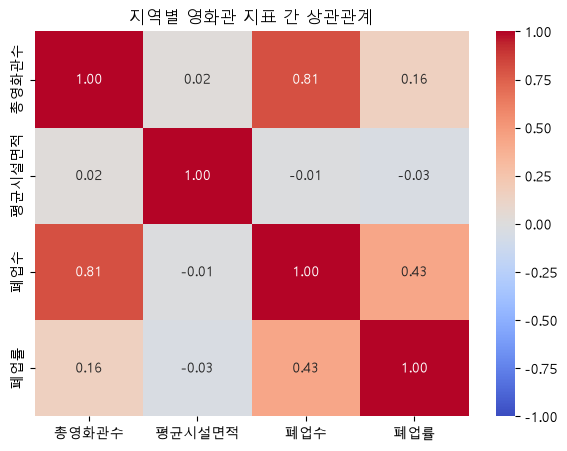

In [49]:
# ----------------------------------------------------
# 1. 지역명 파생변수 추출 (도로명주소에서 '시/군/구' 단위 추출)
# ----------------------------------------------------
# 예: "서울특별시 종로구 경희궁1길..." -> "서울특별시 종로구"
df['시군구'] = df['도로명주소'].str.split().str[:2].str.join(' ')

# ----------------------------------------------------
# 2. 지역별 집계 (GroupBy)
# ----------------------------------------------------
# (1) 지역별 전체 영화관 수 및 평균 면적
df_region = df.groupby('시군구').agg(
    총영화관수=('사업장명', 'count'),
    평균시설면적=('시설면적', 'mean')
).reset_index()

print("=====================")
print("지역별집계")
print(df_region)
print("=====================")



# (2) 지역별 폐업 영화관 수
df_closed = df[df['영업상태명'] == '폐업'].groupby('시군구')['사업장명'].count().reset_index()
df_closed.columns = ['시군구', '폐업수']

# (3) 데이터 합치기 및 폐업률 계산
df_analysis = pd.merge(df_region, df_closed, on='시군구', how='left').fillna(0)
df_analysis['폐업률'] = df_analysis['폐업수'] / df_analysis['총영화관수']

# ----------------------------------------------------
# 3. 상관계수 행렬 산출
# ----------------------------------------------------
corr_cols = ['총영화관수', '평균시설면적', '폐업수', '폐업률']
corr_matrix = df_analysis[corr_cols].corr()

print("=== 지역별 수치 상관계수 ===")
print(corr_matrix)

# ----------------------------------------------------
# 4. 히트맵(Heatmap) 시각화
# ----------------------------------------------------
plt.rc('font', family='Malgun Gothic') # Windows 한글 폰트 (Mac은 AppleGothic)
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("지역별 영화관 지표 간 상관관계")
plt.show()

# ----------------------------------------------------
# 5. 산점도(Scatter Plot) 시각화 (예: 평균시설면적 vs 폐업률)
# ----------------------------------------------------
fig = px.scatter(
    df_analysis,
    x='평균시설면적',
    y='폐업률',
    size='총영화관수',      # 원 크기로 해당 지역의 총 영화관 수 표현
    hover_name='시군구',   # 마우스 올렸을 때 지역명 표시
    trendline='ols',       # 상관관계 추세선
    title='지역별 평균 영화관 면적과 폐업률의 상관관계'
)
fig.show()

In [54]:

# ----------------------------------------------------
# 2. 지역별 집계 (GroupBy)
# ----------------------------------------------------
# (1) 지역별 전체 영화관 수 및 평균 면적
df_region = df.groupby('시군구').agg(
    총영화관수=('사업장명', 'count'),
    평균시설면적=('시설면적', 'mean')
).reset_index()

print("=====================")
print("지역별집계")
display(df_region)
print("=====================")


# (2) 지역별 폐업 영화관 수
df_closed = df[df['영업상태명'] == '폐업'].groupby('시군구')['사업장명'].count().reset_index()
df_closed.columns = ['시군구', '폐업수']

print("=====================")
print("지역별폐업수")
display(df_closed)
print("=====================")



지역별집계


,시군구,총영화관수,평균시설면적
0,강원특별자치도 강릉시,20,NaN
1,강원특별자치도 고성군,3,NaN
2,강원특별자치도 동해시,7,NaN
3,강원특별자치도 삼척시,7,NaN
4,강원특별자치도 속초시,14,NaN
...,...,...,...
212,충청북도 음성군,7,NaN
213,충청북도 제천시,23,NaN
214,충청북도 증평군,1,NaN
215,충청북도 청주시,105,NaN


지역별폐업수


,시군구,폐업수
0,강원특별자치도 강릉시,6
1,강원특별자치도 동해시,2
2,강원특별자치도 삼척시,3
3,강원특별자치도 속초시,6
4,강원특별자치도 원주시,2
...,...,...
137,충청남도 홍성군,1
138,충청북도 제천시,9
139,충청북도 증평군,1
140,충청북도 청주시,29


In [55]:
import numpy as np
import pandas as pd

# '시설면적'이 숫자형인지 사전 확인 (아까 NaN 방지용)
df['시설면적'] = pd.to_numeric(df['시설면적'], errors='coerce')

# SQL처럼 한 번에 (한 방) 집계하기
df_analysis = df.groupby('시군구').agg(
    총영화관수=('사업장명', 'count'),
    평균시설면적=('시설면적', 'mean'),
    폐업수=('영업상태명', lambda x: (x == '폐업').sum()),          # SQL의 COUNT(CASE WHEN...)과 동일
    폐업률=('영업상태명', lambda x: (x == '폐업').mean())          # 폐업인 비율 (0~1)
).reset_index()

# 확인
display(df_analysis)

,시군구,총영화관수,평균시설면적,폐업수,폐업률
0,강원특별자치도 강릉시,20,NaN,6,0.300000
1,강원특별자치도 고성군,3,NaN,0,0.000000
2,강원특별자치도 동해시,7,NaN,2,0.285714
3,강원특별자치도 삼척시,7,NaN,3,0.428571
4,강원특별자치도 속초시,14,NaN,6,0.428571
...,...,...,...,...,...
212,충청북도 음성군,7,NaN,0,0.000000
213,충청북도 제천시,23,NaN,9,0.391304
214,충청북도 증평군,1,NaN,1,1.000000
215,충청북도 청주시,105,NaN,29,0.276190


In [56]:
# '시설면적'에 어떤 값들이 들어있는지 10개만 확인
print(df['시설면적'].head(10))

# 데이터 타입 및 결측치 개수 확인
print("전체 개수:", len(df))
print("숫자 변환 실패(NaN) 개수:", pd.to_numeric(df['시설면적'], errors='coerce').isna().sum())

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: 시설면적, dtype: float64
전체 개수: 5233
숫자 변환 실패(NaN) 개수: 5142


In [57]:
df_clean = df.copy()

In [66]:
print("시설면적 NaN:",df_clean["시설면적"].isna().sum())
print("전체개수:",len(df_clean))

시설면적 NaN: 5142
전체개수: 5233


In [68]:
print("인허가일자 NaN:",df_clean["인허가일자"].isna().sum())
print("폐업일자 NaN:",df_clean["폐업일자"].isna().sum())
print("영업상태명 NaN:",df_clean["영업상태명"].isna().sum())
print("도로명주소 NaN:",df_clean["도로명주소"].isna().sum())

인허가일자 NaN: 0
폐업일자 NaN: 3701
영업상태명 NaN: 0
도로명주소 NaN: 362


=== 지역별 영업기간 및 폐업률 집계 ===


,시군구,총영화관수,평균영업기간_년,폐업수,폐업률
0,강원특별자치도 강릉시,20,11.774658,6,0.300000
1,강원특별자치도 고성군,3,11.329680,0,0.000000
2,강원특별자치도 동해시,7,14.183953,2,0.285714
3,강원특별자치도 삼척시,7,7.832877,3,0.428571
4,강원특별자치도 속초시,14,13.703523,6,0.428571
5,강원특별자치도 양구군,4,5.062329,0,0.000000
6,강원특별자치도 양양군,2,7.276712,0,0.000000
7,강원특별자치도 영월군,2,11.093151,0,0.000000
8,강원특별자치도 원주시,45,16.651629,2,0.044444
9,강원특별자치도 인제군,5,14.178082,1,0.200000



=== 상관계수 행렬 ===


,총영화관수,평균영업기간_년,폐업수,폐업률
총영화관수,1.000000,0.312929,0.810064,0.156083
평균영업기간_년,0.312929,1.000000,0.203747,0.023390
폐업수,0.810064,0.203747,1.000000,0.432684
폐업률,0.156083,0.023390,0.432684,1.000000


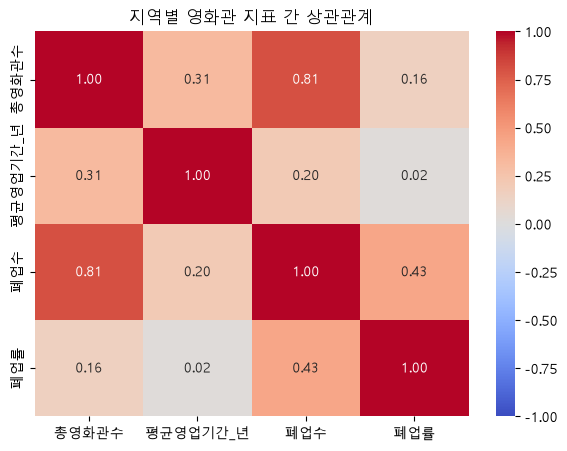

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 시군구 및 영업기간(년) 파생변수 생성
# ----------------------------------------------------
# (1) 주소에서 '시군구' 추출
df['시군구'] = df['도로명주소'].str.split().str[:2].str.join(' ')

# (2) 날짜 데이터 변환
df['인허가일자'] = pd.to_datetime(df['인허가일자'], errors='coerce')
df['폐업일자'] = pd.to_datetime(df['폐업일자'], errors='coerce')

# (3) 영업기간(년 단위) 계산: 폐업한 곳은 (폐업일 - 인허가일), 영업 중인 곳은 (오늘 - 인허가일)
today = pd.to_datetime('today')
df['영업기간_년'] = (df['폐업일자'].fillna(today) - df['인허가일자']).dt.days / 365

# ----------------------------------------------------
# 2. 지역별 한 방 집계 (SQL 스타일)
# ----------------------------------------------------
df_analysis = df.groupby('시군구').agg(
    총영화관수=('사업장명', 'count'),
    평균영업기간_년=('영업기간_년', 'mean'),
    폐업수=('영업상태명', lambda x: (x == '폐업').sum()),
    폐업률=('영업상태명', lambda x: (x == '폐업').mean())
).reset_index()

# 집계 결과 확인 (10개만 출력)
print("=== 지역별 영업기간 및 폐업률 집계 ===")
display(df_analysis.head(10))

# ----------------------------------------------------
# 3. 상관계수 확인 및 시각화
# ----------------------------------------------------
corr_matrix = df_analysis[['총영화관수', '평균영업기간_년', '폐업수', '폐업률']].corr()

print("\n=== 상관계수 행렬 ===")
display(corr_matrix)

# 히트맵 시각화
plt.rc('font', family='Malgun Gothic') # Windows 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("지역별 영화관 지표 간 상관관계")
plt.show()

In [82]:
df_clean = df.copy()

df_clean['시군구'] = df_clean['도로명주소'].str[:2].str.join(' ')

df_clean['인허가일자'] = pd.to_datetime(df_clean['인허가일자'], errors='coerce')
df_clean['폐업일자'] = pd.to_datetime(df_clean['폐업일자'], errors='coerce')

today = pd.to_datetime('today')

df_clean['영업기간_년'] = (df['폐업일자'].fillna(today)  - df['인허가일자']).dt.days / 365


df_final_clean = df_clean.groupby('시군구').agg(

                    총영화관수 = ('사업장명','count'), 
                    평균영업기간 = ('영업기간_년','mean'),
                    폐업수=('영업상태명', lambda x: (x == '폐업').sum()),
                    폐업율=('영업상태명', lambda x: (x == '폐업').mean())              

                ).reset_index()


print("=== 지역별 영업기간 및 폐업률 집계 ===")
display(df_final_clean.head(10))


fig = px.bar(data_frame=df_final_clean, 
             x="시군구",
             y="총영화관수",
             color="폐업율",
             color_continuous_scale="RdYlGn_r",
             title="시군구별 총영화관수"
             )

fig.update_layout(width=800,height=500)
fig.show()




=== 지역별 영업기간 및 폐업률 집계 ===


,시군구,총영화관수,평균영업기간,폐업수,폐업율
0,강 원,178,12.931692,28,0.157303
1,경 기,1227,12.315024,266,0.216789
2,경 상,476,13.574888,114,0.239496
3,광 주,1,27.191781,0,0.000000
4,대 구,245,13.098574,87,0.355102
5,대 전,156,14.296927,50,0.320513
6,부 산,311,14.561239,86,0.276527
7,서 울,911,14.817581,274,0.300768
8,세 종,24,9.430708,0,0.000000
9,울 산,92,11.770161,25,0.271739


In [84]:
# 1. 원본 데이터프레임(df)의 손상을 막기 위해 복사본(df_clean) 생성
df_clean = df.copy()

# 2. '도로명주소' 문자열의 앞 2글자를 추출하고 글자 사이에 공백(' ')을 넣어 '시군구' 컬럼 생성
# (예: '서울...' -> '서 울')
df_clean['시군구'] = df_clean['도로명주소'].str[:2].str.join(' ')

# 3. '인허가일자'와 '폐업일자'의 문자열을 파이썬 날짜(datetime) 객체로 변환
# errors='coerce': 날짜 형식이 잘못되었거나 빈 값인 경우 에러 없이 NaT(빈값)로 처리
df_clean['인허가일자'] = pd.to_datetime(df_clean['인허가일자'], errors='coerce')
df_clean['폐업일자'] = pd.to_datetime(df_clean['폐업일자'], errors='coerce')

# 4. 아직 영업 중인 매장의 영업기간을 계산하기 위해 현재(오늘) 날짜 시점 생성
today = pd.to_datetime('today')

# 5. 영업기간(년 단위 수치) 변수 생성
# - df['폐업일자'].fillna(today): 폐업일자가 없는(영업 중인) 곳은 오늘 날짜로 채움
# - 인허가일자와의 차이를 구한 뒤 .dt.days로 '일 수(숫자)'만 추출하여 365로 나눠 연 단위 환산
df_clean['영업기간_년'] = (df['폐업일자'].fillna(today) - df_clean['인허가일자']).dt.days / 365


# 6. '시군구'별로 그룹화하여 다중 집계 연산 수행 (.groupby().agg())
df_final_clean = df_clean.groupby('시군구').agg(
    # [1] 총영화관수: 각 시군구 그룹 내 사업장명 전체 개수 세기 (count)
    총영화관수 = ('사업장명', 'count'), 
    
    # [2] 평균영업기간: 위에서 만든 '영업기간_년'의 평균값 계산 (mean)
    평균영업기간 = ('영업기간_년', 'mean'),
    
    # [3] 폐업수: 영업상태명이 '폐업'인 데이터의 개수만 합산 (sum)
    폐업수 = ('영업상태명', lambda x: (x == '폐업').sum()),
    
    # [4] 폐업율: 전체 개수 중 '폐업' 상태가 차지하는 비율 계산 (mean)
    폐업율 = ('영업상태명', lambda x: (x == '폐업').mean())              

# .reset_index(): 그룹화로 인덱스가 된 '시군구'를 일반 데이터 컬럼으로 되돌림
).reset_index()


# 7. 집계 결과를 확인하기 위해 상위 10개 행 출력
print("=== 지역별 영업기간 및 폐업률 집계 ===")
display(df_final_clean.head(10))


# 8. Plotly 막대그래프(px.bar) 시각화 객체 생성
fig = px.bar(
    data_frame = df_final_clean,          # 차트에 사용할 집계 데이터프레임
    x = "시군구",                         # X축: 시군구 명칭
    y = "총영화관수",                      # Y축: 총영화관수 (막대 높이)
    color = "폐업율",                     # 막대 색상 지표: '폐업율' 수치에 따라 채색
    color_continuous_scale = "RdYlGn_r",  # 색상 범위: 초록(낮음) -> 노랑(중간) -> 빨강(높음) 반전 스케일
    title = "시군구별 총영화관수"            # 그래프 제목
)

# 9. 그래프 가로/세로 크기(픽셀) 설정
fig.update_layout(width=800, height=500)

# 10. 그래프 최종 출력
fig.show()

=== 지역별 영업기간 및 폐업률 집계 ===


,시군구,총영화관수,평균영업기간,폐업수,폐업율
0,강 원,178,12.931692,28,0.157303
1,경 기,1227,12.315024,266,0.216789
2,경 상,476,13.574888,114,0.239496
3,광 주,1,27.191781,0,0.000000
4,대 구,245,13.098574,87,0.355102
5,대 전,156,14.296927,50,0.320513
6,부 산,311,14.561239,86,0.276527
7,서 울,911,14.817581,274,0.300768
8,세 종,24,9.430708,0,0.000000
9,울 산,92,11.770161,25,0.271739
